In [ ]:
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectPercentile, f_regression
from sklearn.linear_model import Ridge

SEED = 2026
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

def make_preprocess(leakage_type: str):
    if leakage_type == "scaler":
        return StandardScaler()
    if leakage_type == "select_percentile":
        return SelectPercentile(score_func=f_regression, percentile=5)
    raise ValueError(leakage_type)

def make_model():
    return Ridge(alpha=1.0)

def good_cv_rmse(X, y, preprocess, model, cv):
    # GOOD: preprocessing is fitted inside CV via Pipeline
    pipe = Pipeline([("pre", preprocess), ("model", model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="neg_root_mean_squared_error")
    return float(-scores.mean()), float(scores.std())

def bad_cv_rmse(X, y, preprocess, model, cv):
    # BAD: intentional leakage — preprocess sees all data before CV
    Xt = preprocess.fit_transform(X, y)
    scores = cross_val_score(model, Xt, y, cv=cv, scoring="neg_root_mean_squared_error")
    return float(-scores.mean()), float(scores.std())

def run_one(student_or_team, seed, dataset_name, dataset_params_dict,
            sweep_param, sweep_value, leakage_type, X, y, cv):
    pre = make_preprocess(leakage_type)
    model = make_model()

    bad_mean, _ = bad_cv_rmse(X, y, pre, model, cv)

    # Important: use fresh objects for GOOD (do not reuse after bad_cv_rmse)
    good_mean, _ = good_cv_rmse(X, y, make_preprocess(leakage_type), make_model(), cv)

    optimism_pct = (good_mean - bad_mean) / max(good_mean, 1e-12) * 100.0

    return {
        "student_or_team": student_or_team,
        "seed": seed,
        "dataset_name": dataset_name,
        "dataset_params": json.dumps(dataset_params_dict, ensure_ascii=False),
        "sweep_param": sweep_param,
        "sweep_value": sweep_value,
        "leakage_type": leakage_type,
        "bad_cv_rmse": bad_mean,
        "good_cv_rmse": good_mean,
        "optimism_pct": optimism_pct,
    }


# Lab01 — протокол результатов (минимальный)

В этом ноутбуке **уже есть готовые функции**, которые считают *правильную* и *неправильную* оценку качества
(то есть **GOOD vs BAD**) и помогают собрать результаты в одну таблицу `results.csv`.

## Что нужно сделать студенту (очень коротко)

### 1) Сгенерировать 2 типа данных (регрессия)
Можно использовать `sklearn.datasets.make_regression`.

**Датасет A: “мало объектов, много признаков”**
- Например: `n ≈ 120`, а число признаков `d` большое.
- Сделайте перебор (sweep) по `d`: **3 значения** (например 300, 1000, 3000).

**Датасет B: “признаки похожи друг на друга (коррелированы)”**
- Интуиция: данные можно хорошо описать несколькими “общими факторами”.
- В `make_regression` это удобно задавать параметром `effective_rank`.
- Сделайте перебор по `effective_rank`: **3 значения** (например 5, 10, 20).

> Можно выбрать другие числа, но важно: для A и для B должно быть по 3 режима.

### 2) Для каждого режима сравнить 2 вида утечки (фиксированы)
- `scaler` — стандартизация признаков (`StandardScaler`)  
- `select_percentile` — отбор части признаков по их связи с `y` (`SelectPercentile(f_regression, ...)`)

### 3) Каждый эксперимент прогонять через `run_one`
**Один вызов `run_one(...)` = одна строка результата.**  
Для каждого режима данных нужно сделать два вызова:
- один раз с `leakage_type="scaler"`
- один раз с `leakage_type="select_percentile"`

Итого минимум строк:
- A: 3 режима × 2 leakage = 6 строк  
- B: 3 режима × 2 leakage = 6 строк  
**Всего минимум: 12 строк.**

### 4) Собрать строки в список `rows` и сохранить таблицу
- Вы добавляете словари в список `rows` (через `rows.append(run_one(...))`).
- В конце вызываете `save_results_csv(rows)` — появится файл `results.csv` в едином формате.

## Что считается (смысл GOOD vs BAD)
- **GOOD:** preprocessing обучается **внутри** CV через `Pipeline` (в каждом fold заново).
- **BAD:** preprocessing обучается **один раз до CV** на всех данных (`fit_transform(X, y)`), из‑за этого оценка обычно получается слишком оптимистичной.

## Что сдавать
1) Ваш ноутбук/скрипт, который:
   - создаёт A и B (с перебором 3 значений для каждого),
   - формирует `rows` через `run_one`,
   - сохраняет `results.csv` через `save_results_csv`.
2) `results.csv` (минимум 12 строк)
3) 10–15 строк текста (в конце ноутбука или отдельным файлом):
   - где “optimism” больше и почему,
   - и одно правило: как правильно делать оценку в sklearn (preprocessing внутри CV).

### Обязательно: график
Постройте график зависимости `optimism_pct` от параметра перебора (`sweep_value`) отдельно для датасета A и для датасета B.
На каждом графике должно быть две линии: `scaler` и `select_percentile`.


In [ ]:
import pandas as pd

REQUIRED_COLS = [
    "student_or_team", "seed",
    "dataset_name", "dataset_params",
    "sweep_param", "sweep_value",
    "leakage_type",
    "bad_cv_rmse", "good_cv_rmse", "optimism_pct",
]

def save_results_csv(rows, path="results.csv"):
    """
    rows: list[dict], где каждый dict содержит REQUIRED_COLS
    Сохраняет results.csv в едином формате и делает простую валидацию.
    """
    df = pd.DataFrame(rows)

    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    df = df[REQUIRED_COLS].copy()

    if len(df) < 12:
        raise ValueError(f"Expected at least 12 rows (got {len(df)}).")

    df.to_csv(path, index=False)
    return df


In [ ]:
#Ваш код

#from sklearn.datasets import make_regression

#STUDENT_OR_TEAM = "solution"
#rows = []

# -------------------------
# Dataset A: small n, high d
# Sweep over d
# -------------------------



# ------------------------------
# Dataset B: correlated features
# Sweep over effective_rank
# ------------------------------


,student_or_team,seed,dataset_name,dataset_params,sweep_param,sweep_value,leakage_type,bad_cv_rmse,good_cv_rmse,optimism_pct
0,solution,2026,A_small_n_high_d,"{""n"": 120, ""d"": 300, ""n_informative"": 20, ""noi...",d,300,scaler,209.408668,209.776793,0.175484
1,solution,2026,A_small_n_high_d,"{""n"": 120, ""d"": 300, ""n_informative"": 20, ""noi...",d,300,select_percentile,126.550933,156.596025,19.186369
2,solution,2026,A_small_n_high_d,"{""n"": 120, ""d"": 1000, ""n_informative"": 20, ""no...",d,1000,scaler,235.087944,234.801404,-0.122035
3,solution,2026,A_small_n_high_d,"{""n"": 120, ""d"": 1000, ""n_informative"": 20, ""no...",d,1000,select_percentile,135.620152,175.564203,22.751820
4,solution,2026,A_small_n_high_d,"{""n"": 120, ""d"": 3000, ""n_informative"": 20, ""no...",d,3000,scaler,277.917676,277.446211,-0.169931
5,solution,2026,A_small_n_high_d,"{""n"": 120, ""d"": 3000, ""n_informative"": 20, ""no...",d,3000,select_percentile,152.470223,281.917894,45.916798
6,solution,2026,B_correlated,"{""n"": 500, ""d"": 80, ""n_informative"": 10, ""nois...",effective_rank,5,scaler,27.708323,27.708059,-0.000953
7,solution,2026,B_correlated,"{""n"": 500, ""d"": 80, ""n_informative"": 10, ""nois...",effective_rank,5,select_percentile,25.059583,25.100442,0.162785
8,solution,2026,B_correlated,"{""n"": 500, ""d"": 80, ""n_informative"": 10, ""nois...",effective_rank,10,scaler,27.321105,27.321215,0.000402
9,solution,2026,B_correlated,"{""n"": 500, ""d"": 80, ""n_informative"": 10, ""nois...",effective_rank,10,select_percentile,24.656566,24.745820,0.360682


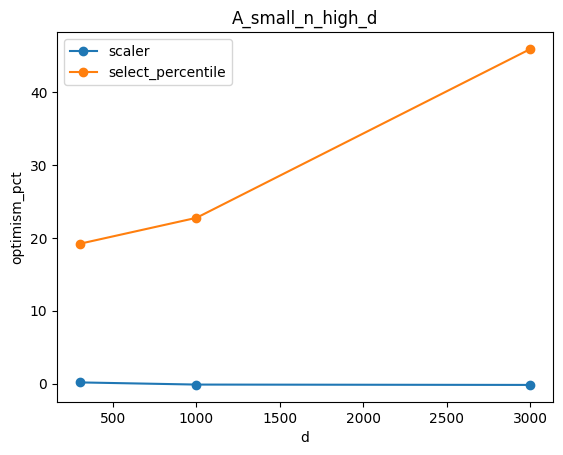

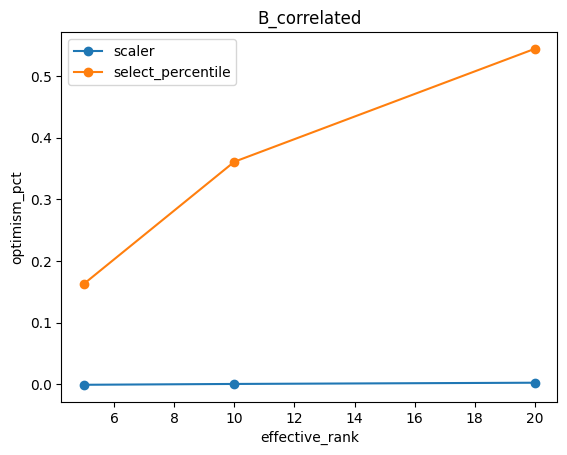

In [ ]:
import matplotlib.pyplot as plt

for ds in ["A_small_n_high_d", "B_correlated"]:
    sub = df[df["dataset_name"] == ds].copy()
    plt.figure()
    for leak in ["scaler", "select_percentile"]:
        s = sub[sub["leakage_type"] == leak].sort_values("sweep_value")
        plt.plot(s["sweep_value"], s["optimism_pct"], marker="o", label=leak)
    plt.xlabel(sub["sweep_param"].iloc[0])
    plt.ylabel("optimism_pct")
    plt.title(ds)
    plt.legend()
    plt.show()


## Короткий вывод (по полученным числам, 10–15 строк)

